# 1. Installing or Importing necessary libraries

In [91]:
#!pip install odfpy

In [113]:
import pandas as pd
import numpy as np
from dotenv import dotenv_values
from sqlalchemy import create_engine, types
from sqlalchemy.dialects.postgresql import JSON as postgres_json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 2. Definition of function for reading and cleaning datasets

In [ ]:
# Function for cleaning the files
# it takes 4 arguments: year (value from 2017 to 2024), data_type ( "Cargo" or "Passengers"), and country ("DE" or "ES"), and unit ("volume" or "flights")
def clean_aviation_file(year, data_type, country, unit="volume"):
    
    # SHEET NAMES ARE DIFFERENT BETWEEN GERMANY AND SPAIN, AND BETWEEN CARGO AND PASSENGERS.
    prefix = "ES_" if country == "ES" else ""
    suffix = "f" if unit == "flights" else ""

    sheet_name = f"{prefix}{data_type}{str(year)[2:]}{suffix}"
    filename = "/Users/nataliastroher/BootCamp/Capstone-Project/Data/" + f"{country}_{data_type}_{year}.xlsx"
    
    df = pd.read_excel(filename, sheet_name=sheet_name, header=8)
    
    # DROP EMPTY COLUMNS
    df = df.dropna(axis=1, how="all")
    
    # SKIP DUPLICATE HEADER ROW
    df = df.iloc[1:].reset_index(drop=True)
    
    # SAVE 'b' FLAG ROWS BEFORE CLEANING
    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    if unnamed_cols:
        # Find rows where any unnamed column is not NaN
        b_mask = df[unnamed_cols].notna().any(axis=1)
        if b_mask.any():
            b_df = df[b_mask][["TIME"] + unnamed_cols].copy()
            b_df["source_file"] = filename
            b_filename = f"/Users/nataliastroher/BootCamp/Capstone-Project/Data/b_flags_{country}_{data_type}_{year}.csv"
            b_df.to_csv(b_filename, index=False)
            print(f"  ⚠️ b flags saved to {b_filename} — {b_mask.sum()} rows affected")
    
    # DROP UNNAMED COLUMNS
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    
    # REPLACE MISSING VALUES
    df = df.replace(":", np.nan)
    df = df.replace("not available", np.nan)
    
    # FILTER VALID ROUTES ONLY
    df = df[df["TIME"].str.contains(" - ", na=False)]
    
    # SPLIT TIME INTO ORIGIN & DESTINATION
    # This column name is coming from eurostat, from a double header-line, after reading into df. The actual content is routes. )  
    df[["origin", "destination"]] = df["TIME"].str.split(" - ", n=1, expand=True)
    df = df.drop(columns=["TIME"])

    # ADD NEW COLUMNS (required for the later merge of the 4 countries)
    df.insert(0, "origin_country", country)
    df.insert(2, "year", int(year))
    
    # RENAME MONTH COLUMNS FROM "2017-01" TO "01" (year has been created in the step before; redundant) 
    month_cols = {c: c.split("-")[1] for c in df.columns if "-" in str(c)}
    df = df.rename(columns=month_cols)
    
    # REORDER COLUMNS (defining a more suitable order)
    other_cols = [c for c in df.columns if c not in ["origin_country", "origin", "destination", "year"]]
    df = df[["origin_country", "origin", "destination", "year"] + other_cols]
    
    # CONVERT MONTH COLUMNS (int - if it is Passengers, float - if it is Cargo)
    month_cols = [c for c in df.columns if c not in ["origin_country", "origin", "destination", "year"]]
    if data_type == "Passengers":
        df[month_cols] = df[month_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")
    else:
        df[month_cols] = df[month_cols].apply(pd.to_numeric, errors="coerce").astype("Float64")
    
    #print(f"✓ {filename} — shape: {df.shape}")
    return df

# 3. Calling the function

In [101]:
# DEFINITION OF DICTIONARIES FOR EACH COUNTRY, DATA TYPE AND UNIT
passengers_dfs_de = {}
passengers_flights_dfs_de = {}
cargo_dfs_de = {}
cargo_flights_dfs_de = {}
  
passengers_dfs_es = {}
passengers_flights_dfs_es = {}  
cargo_dfs_es = {}
cargo_flights_dfs_es = {}

#YEARS TO LOOP THROUGH
years = range(2017, 2025)
   
dict_map = {
    ("DE", "Cargo", "volume"): cargo_dfs_de,
    ("DE", "Cargo", "flights"): cargo_flights_dfs_de,
    ("DE", "Passengers", "volume"): passengers_dfs_de,
    ("DE", "Passengers", "flights"): passengers_flights_dfs_de,
    ("ES", "Cargo", "volume"): cargo_dfs_es,
    ("ES", "Cargo", "flights"): cargo_flights_dfs_es,
    ("ES", "Passengers", "volume"): passengers_dfs_es,
    ("ES", "Passengers", "flights"): passengers_flights_dfs_es,
}

# CALLING OF FUNCTION 
for year in years:
    for country in ["DE", "ES"]:
        for data_type in ["Cargo", "Passengers"]:
            for unit in ["volume", "flights"]:
                target_dict = dict_map[(country, data_type, unit)]
                target_dict[f"{country}_{year}"] = clean_aviation_file(year, data_type, country, unit)

✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/DE_Cargo_2017.xlsx — shape: (1720, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/DE_Cargo_2017.xlsx — shape: (1720, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/DE_Passengers_2017.xlsx — shape: (2352, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/DE_Passengers_2017.xlsx — shape: (2352, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/ES_Cargo_2017.xlsx — shape: (1190, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/ES_Cargo_2017.xlsx — shape: (1190, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/ES_Passengers_2017.xlsx — shape: (2083, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/ES_Passengers_2017.xlsx — shape: (2083, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/DE_Cargo_2018.xlsx — shape: (1720, 16)
✓ /Users/nataliastroher/BootCamp/Capstone-Project/Data/DE_Cargo_2018.xlsx — shape: (1720, 16)
✓ /Users/nataliastroher/BootCamp/Capston

In [ ]:
# EXAMPLE OF FUNCTION CALLING FOR A SPECIFIC COUNTRY, DATA TYPE, UNIT, AND YEAR 

#passengers_flights_dfs_de["DE_2018"].head(20)

# 4. Definition of unique destinations 
(required for later mapping the region, subregion, and destination country)

In [96]:
all_destinations_de_es = (
    pd.concat(
        [df["destination"] for df in passengers_dfs_de.values()] +
        [df["destination"] for df in passengers_flights_dfs_de.values()] +
        [df["destination"] for df in cargo_dfs_de.values()] + 
        [df["destination"] for df in cargo_flights_dfs_de.values()] +
        [df["destination"] for df in passengers_dfs_es.values()] +
        [df["destination"] for df in passengers_flights_dfs_es.values()] +
        [df["destination"] for df in cargo_dfs_es.values()] +
        [df["destination"] for df in cargo_flights_dfs_es.values()]
    )
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

In [97]:
all_destinations_de_es.head(20)

0                                A CORUNA airport
1                                  AARHUS airport
2                                  ABAKAN airport
3                           ABERDEEN/DYCE airport
4          ABIDJAN/FELIX HOUPHOUET BOIGNY airport
5               ABU DHABI AL DHAFRA (MIL) airport
6                  ABU DHABI BATEEN (MIL) airport
7                 ABU DHABI INTERNATIONAL airport
8                    ABUJA/NNAMDI AZIKIWE airport
9                               ACCRA ACC airport
10             ACCRA/KOTOKA INTERNATIONAL airport
11                                  ADANA airport
12                   ADANA/INCIRLIK (MIL) airport
13           ADDIS ABABA/BOLE COM/MET/NOF airport
14           ADOLFO SUAREZ MADRID-BARAJAS airport
15    AEROPUERTO INTERNACIONAL EL SAVADOR airport
16                      AGADIR/AL MASSIRA airport
17                        AGADIR/INEZGANE airport
18        AGUADILLA/RAPHAEL HERNANDEZ PR. airport
19                              AHMEDABAD airport


In [98]:
all_destinations_de_es.to_csv("/Users/nataliastroher/BootCamp/Capstone-Project/data/all_destinations_de_es.csv", index=False)

# 5. Mapping Region, Subregion, and Destination Country

In [ ]:
lookup = pd.read_excel("/Users/nataliastroher/BootCamp/Capstone-Project/Data/destinations_with_regions_v2.xlsx")

all_dicts = [
    passengers_dfs_de, passengers_flights_dfs_de,
    cargo_dfs_de, cargo_flights_dfs_de,
    passengers_dfs_es, passengers_flights_dfs_es,
    cargo_dfs_es, cargo_flights_dfs_es
]

for d in all_dicts:
    for key in d:
        d[key] = d[key].merge(lookup, on="destination", how="left")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/nataliastroher/BootCamp/Capstone-Project/Data/destinations_with_regions_1.csv'

In [ ]:
# Collect all unknown destinations across all dictionaries
unknown_dfs = []

for d_name, d in [
    ("passengers_DE", passengers_dfs_de),
    ("passengers_flights_DE", passengers_flights_dfs_de),
    ("cargo_DE", cargo_dfs_de),
    ("cargo_flights_DE", cargo_flights_dfs_de),
    ("passengers_ES", passengers_dfs_es),
    ("passengers_flights_ES", passengers_flights_dfs_es),
    ("cargo_ES", cargo_dfs_es),
    ("cargo_flights_ES", cargo_flights_dfs_es),
]:
    for key, df in d.items():
        mask = df["region"].isin(["Unknown", "Unknown - Country Level"]) | df["region"].isna()
        if mask.any():
            temp = df[mask][["destination", "region", "destination_country"]].copy()
            temp["source"] = d_name
            unknown_dfs.append(temp)

# Combine and deduplicate
unknowns_export = pd.concat(unknown_dfs, ignore_index=True).drop_duplicates(subset=["destination"])
unknowns_export = unknowns_export.sort_values("region")

print(f"Unique unknown destinations: {len(unknowns_export)}")
unknowns_export.to_csv("/Users/nataliastroher/BootCamp/Capstone-Project/Data/unknown_destinations2.csv", index=False)
print("Saved!")

Unique unknown destinations: 5
Saved!


# 5.1 Rerun mapping 
(after manual modification of unknown - columns needed to be dropped first)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 1. LOAD UPDATED LOOKUP TABLE
# ─────────────────────────────────────────────────────────────────

lookup = pd.read_excel("/Users/nataliastroher/BootCamp/Capstone-Project/Data/destinations_with_regions_v2.xlsx")

print(f"Lookup loaded: {len(lookup)} destinations")
print(f"Region distribution:\n{lookup['region'].value_counts()}\n")

# ─────────────────────────────────────────────────────────────────
# 2. APPLY LOOKUP TO ALL DICTIONARIES
#    - Drops existing region columns first to avoid _x/_y conflicts
#    - Then merges cleanly
# ─────────────────────────────────────────────────────────────────

region_cols = ["region", "subregion", "destination_country"]

all_dicts = {
    "passengers_DE":         passengers_dfs_de,
    "passengers_flights_DE": passengers_flights_dfs_de,
    "cargo_DE":              cargo_dfs_de,
    "cargo_flights_DE":      cargo_flights_dfs_de,
    "passengers_ES":         passengers_dfs_es,
    "passengers_flights_ES": passengers_flights_dfs_es,
    "cargo_ES":              cargo_dfs_es,
    "cargo_flights_ES":      cargo_flights_dfs_es,
}

for dict_name, d in all_dicts.items():
    print(f"Processing {dict_name}...")
    for key in d:
        # Drop existing region columns if present (avoids _x/_y conflict)
        d[key] = d[key].drop(columns=region_cols, errors="ignore")
        # Merge with updated lookup
        d[key] = d[key].merge(lookup, on="destination", how="left")
    print(f"  ✓ {len(d)} dataframes updated")

# ─────────────────────────────────────────────────────────────────
# 3. VERIFY - Check unknowns after merge
# ─────────────────────────────────────────────────────────────────

print("\n--- Unknown check after merge ---")
for dict_name, d in all_dicts.items():
    for key, df in d.items():
        unknown = (df["region"] == "Unknown").sum()
        nan = df["region"].isna().sum()
        if unknown > 0 or nan > 0:
            print(f"  {dict_name} {key}: Unknown={unknown}, NaN={nan}")

print("\nDone! All dictionaries updated with region mapping.")


Lookup loaded: 799 destinations
Region distribution:
region
Europe           395
Asia Pacific     118
Africa            90
North America     88
Latin America     67
Middle East       36
Unknown            5
Name: count, dtype: int64

Processing passengers_DE...
  ✓ 8 dataframes updated
Processing passengers_flights_DE...
  ✓ 8 dataframes updated
Processing cargo_DE...
  ✓ 8 dataframes updated
Processing cargo_flights_DE...
  ✓ 8 dataframes updated
Processing passengers_ES...
  ✓ 8 dataframes updated
Processing passengers_flights_ES...
  ✓ 8 dataframes updated
Processing cargo_ES...
  ✓ 8 dataframes updated
Processing cargo_flights_ES...
  ✓ 8 dataframes updated

--- Unknown check after merge ---
  passengers_DE DE_2017: Unknown=6, NaN=0
  passengers_DE DE_2018: Unknown=6, NaN=0
  passengers_DE DE_2019: Unknown=6, NaN=0
  passengers_DE DE_2020: Unknown=6, NaN=0
  passengers_DE DE_2021: Unknown=6, NaN=0
  passengers_DE DE_2022: Unknown=6, NaN=0
  passengers_DE DE_2023: Unknown=6, NaN=0
 

# 6. Function 'MELT_TO_LONG' 
(for converting wide into long)


In [55]:
def melt_to_long(volume_dfs, flights_dfs, value_name):
    """
    Combines volume (passengers/cargo) and flights dictionaries into one long dataframe,
    with separate columns for the value and flights.
    """
    all_rows = []
    
    for key in volume_dfs:
        vol_df = volume_dfs[key].copy()
        flights_df = flights_dfs[key].copy()
        
        month_cols = [c for c in vol_df.columns if c.isdigit()]
        id_cols = [c for c in vol_df.columns if c not in month_cols]
        
        # Melt volume
        vol_long = vol_df.melt(
            id_vars=id_cols,
            value_vars=month_cols,
            var_name="month",
            value_name=value_name
        )
        
        # Melt flights
        flights_long = flights_df.melt(
            id_vars=id_cols,
            value_vars=month_cols,
            var_name="month",
            value_name="flights"
        )
        
        # Merge them together on the identifier columns + month
        merged = vol_long.merge(
            flights_long[id_cols + ["month", "flights"]],
            on=id_cols + ["month"],
            how="left"
        )
        
        all_rows.append(merged)
    
    return pd.concat(all_rows, ignore_index=True)

# 6.1 Converting Passengers (DE)

In [56]:
passengers_long_de = melt_to_long(passengers_dfs_de, passengers_flights_dfs_de, "passengers")

In [58]:
passengers_long_de.info()

<class 'pandas.DataFrame'>
RangeIndex: 225792 entries, 0 to 225791
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   origin_country       225792 non-null  str  
 1   origin               225792 non-null  str  
 2   destination          225792 non-null  str  
 3   year                 225792 non-null  int64
 4   region               225792 non-null  str  
 5   subregion            225792 non-null  str  
 6   destination_country  225600 non-null  str  
 7   month                225792 non-null  str  
 8   passengers           76484 non-null   Int64
 9   flights              76516 non-null   Int64
dtypes: Int64(2), int64(1), str(7)
memory usage: 17.7 MB


In [59]:
passengers_long_de.head

<bound method NDFrame.head of        origin_country                      origin  \
0                  DE                     UNKNOWN   
1                  DE                     UNKNOWN   
2                  DE                     UNKNOWN   
3                  DE  BERLIN-BRANDENBURG airport   
4                  DE  BERLIN-BRANDENBURG airport   
...               ...                         ...   
225787             DE               LAAGE airport   
225788             DE               LAAGE airport   
225789             DE               LAAGE airport   
225790             DE               LAAGE airport   
225791             DE               LAAGE airport   

                                         destination  year       region  \
0       GERMANY airport - BERLIN-BRANDENBURG airport  2017       Europe   
1                  GERMANY airport - HAMBURG airport  2017       Europe   
2             GERMANY airport - BERLIN-TEGEL airport  2017       Europe   
3                    ABU DHABI IN

# 6.2 Converting Passengers (ES)

In [61]:
passengers_long_es = melt_to_long(passengers_dfs_es, passengers_flights_dfs_es, "passengers")

In [60]:
# Confirm both passengers and flights columns are present and correctly typed
print(passengers_long_de.dtypes)

# Check how many rows have NaN in passengers vs flights
print(f"NaN passengers: {passengers_long_de['passengers'].isna().sum()}")
print(f"NaN flights: {passengers_long_de['flights'].isna().sum()}")

# Spot check one route to make sure passengers and flights align correctly
sample = passengers_long_de[
    (passengers_long_de["origin"].str.contains("FRANKFURT", na=False)) &
    (passengers_long_de["destination"].str.contains("DUBAI", na=False)) &
    (passengers_long_de["year"] == 2019)
]
print(sample[["origin", "destination", "year", "month", "passengers", "flights"]])


origin_country           str
origin                   str
destination              str
year                   int64
region                   str
subregion                str
destination_country      str
month                    str
passengers             Int64
flights                Int64
dtype: object
NaN passengers: 149308
NaN flights: 149276
                       origin                  destination  year month  \
56664  FRANKFURT/MAIN airport  DUBAI INTERNATIONAL airport  2019    01   
59016  FRANKFURT/MAIN airport  DUBAI INTERNATIONAL airport  2019    02   
61368  FRANKFURT/MAIN airport  DUBAI INTERNATIONAL airport  2019    03   
63720  FRANKFURT/MAIN airport  DUBAI INTERNATIONAL airport  2019    04   
66072  FRANKFURT/MAIN airport  DUBAI INTERNATIONAL airport  2019    05   
68424  FRANKFURT/MAIN airport  DUBAI INTERNATIONAL airport  2019    06   
70776  FRANKFURT/MAIN airport  DUBAI INTERNATIONAL airport  2019    07   
73128  FRANKFURT/MAIN airport  DUBAI INTERNATIONAL airport  2

# 6.3 Converting Passengers (DE&ES)

In [62]:
cargo_long_de = melt_to_long(cargo_dfs_de, cargo_flights_dfs_de, "cargo")
cargo_long_es = melt_to_long(cargo_dfs_es, cargo_flights_dfs_es, "cargo")

# 7. Concatenating Passengers Long & Cargo Long

In [63]:
passengers_master = pd.concat([
    passengers_long_de,
    passengers_long_es
], ignore_index=True)

print(passengers_master.shape)
print(passengers_master["origin_country"].value_counts())

(428256, 10)
origin_country
DE    225792
ES    202464
Name: count, dtype: int64


In [64]:
cargo_master = pd.concat([
    cargo_long_de,
    cargo_long_es
], ignore_index=True)

print(cargo_master.shape)
print(cargo_master["origin_country"].value_counts())

(280512, 10)
origin_country
DE    165888
ES    114624
Name: count, dtype: int64


# 8. Integration with dBeaver

### 8.1 Connection

In [ ]:
# DB credentials

config = dotenv_values()

In [ ]:
# define variables for the login
pg_user = config['POSTGRES_USER']  
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

In [85]:
# updating the url
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

# creating the engine
engine = create_engine(url, echo=False)

### 8.3 Type dictionaries

In [ ]:
# defining data types for the DB
dtype_dict_passengers = {
    'origin_country':types.String,
    'origin': types.String,
    'destination': types.String,
    'year': types.Integer,
    'region': types.String,
    'subregion':types.String,
    'destination_country': types.String,
    'month': types.Integer,
    'passengers': types.Integer,
    'flights': types.Integer
             }

In [ ]:
# defining data types for the DB
dtype_dict_cargo = {
    'origin_country':types.String,
    'origin': types.String,
    'destination': types.String,
    'year': types.Integer,
    'region': types.String,
    'subregion':types.String,
    'destination_country': types.String,
    'month': types.Integer,
    'cargo': types.Float,
    'flights': types.Integer
             }

# 9. Creating Tables

In [ ]:
capstone_schema = 'group2'
cargo_master.to_sql(name = 'cargo_master', 
                       con = engine, 
                       schema = capstone_schema, 
                       if_exists='append', 
                       #dtype=dtype_dict_cargo,
                       index=False
                      )

passengers_master.to_sql(name = 'passengers_master', 
                       con = engine, 
                       schema = capstone_schema, 
                       if_exists='append',  #'append used as Hendrik has already created the tables in our schema
                       #dtype=dtype_dict_passengers,
                       index=False
                      )

256

# 10. Filling out the columns first and last year

In [ ]:
# columns already created by Hendrik. 
# first year and last year hold the information on when the route was first and last flown.

with engine.begin() as conn:
    conn.execute(text("""UPDATE group2.cargo_master p
                        SET 
                            first_year = route_info.first_year,
                            last_year = route_info.last_year
                        FROM (
                            SELECT 
                                origin,
                                destination,
                                origin_country,
                                MIN(year) as first_year,
                                MAX(year) as last_year
                            FROM group2.cargo_master
                            WHERE cargo IS NOT NULL
                            GROUP BY origin, destination, origin_country
                             ) route_info
                        WHERE p.origin = route_info.origin 
                        AND p.destination = route_info.destination
                        AND p.origin_country = route_info.origin_country;"""))

# 11. Creating a view 
(for all routes that have reported during all 8 years (2017-2024) for passengers to be used in the analysis)

In [90]:
with engine.begin() as conn:
    conn.execute(text("""
        CREATE VIEW group2.passengers_core AS
        SELECT *
        FROM group2.passengers_master
        WHERE passengers IS NOT NULL
        AND flights IS NOT NULL
        AND origin IN (
            'FRANKFURT/MAIN airport',
            'PARIS-CHARLES DE GAULLE airport',
            'ADOLFO SUAREZ MADRID-BARAJAS airport',
            'AMSTERDAM/SCHIPHOL airport'
        )
        AND (origin, destination, origin_country) IN (
            SELECT origin, destination, origin_country
            FROM group2.passengers_master
            WHERE passengers IS NOT NULL
            AND flights IS NOT NULL
            AND origin IN (
                'FRANKFURT/MAIN airport',
                'PARIS-CHARLES DE GAULLE airport',
                'ADOLFO SUAREZ MADRID-BARAJAS airport',
                'AMSTERDAM/SCHIPHOL airport'
            )
            GROUP BY origin, destination, origin_country
            HAVING COUNT(DISTINCT year) = 8
        );
    """))






# 12. EDA - H1 - Passengers/Cargo dropped by more than 50% in 2020 compared to Pre-Covid period. 

### 12.1 Retrieving data from db

In [ ]:

passengers_core = pd.read_sql("SELECT * FROM group2.passengers_core", engine)


In [107]:
# Look into the data
passengers_core.head()
#passengers_core.info()
#passengers_core.describe(include='all')


,origin_country,origin,destination,year,region,subregion,destination_country,month,passengers,flights,first_year,last_year
0,NL,AMSTERDAM/SCHIPHOL airport,DUBAI INTERNATIONAL airport,2018,Middle East,Gulf States,AE,12,79195,272,2017,2024
1,NL,AMSTERDAM/SCHIPHOL airport,CURACAO/AEROPUERTO HATO airport,2018,Latin America,Caribbean,CW,12,47329,131,2017,2024
2,NL,AMSTERDAM/SCHIPHOL airport,WIEN-SCHWECHAT airport,2018,Europe,Western Europe,AT,12,67385,497,2017,2024
3,NL,AMSTERDAM/SCHIPHOL airport,BRUSSELS airport,2018,Europe,Western Europe,BE,12,22320,289,2017,2024
4,NL,AMSTERDAM/SCHIPHOL airport,SAO PAULO/GUARULHOS GOVERNADOR ANDRE FRANCO MO...,2018,Africa,North Africa,MA,12,21797,62,2017,2024


### 12.2 Analysis

In [110]:

# Defining Pre-Covid (2017 to 2019) as baseline
baseline = passengers_core[passengers_core["year"].isin([2017, 2018, 2019])]
baseline_avg = baseline.groupby("origin")["passengers"].sum() / 3

# Totals of 2020 
covid = passengers_core[passengers_core["year"] == 2020]
covid_totals = covid.groupby("origin")["passengers"].sum()

# Drop % 
covid_drop = ((covid_totals - baseline_avg) / baseline_avg) * 100
print("Covid drop percentages by origin:")
print(covid_drop)

Covid drop percentages by origin:
origin
ADOLFO SUAREZ MADRID-BARAJAS airport   -68.061816
AMSTERDAM/SCHIPHOL airport             -67.971911
FRANKFURT/MAIN airport                 -70.019052
PARIS-CHARLES DE GAULLE airport        -67.079669
Name: passengers, dtype: float64


In [111]:
monthly = passengers_core[passengers_core["year"].isin([2019, 2020])]
monthly = monthly.groupby(["origin", "year", "month"])["passengers"].sum().reset_index()
print(monthly)

                                  origin  year  month  passengers
0   ADOLFO SUAREZ MADRID-BARAJAS airport  2019      1     3140229
1   ADOLFO SUAREZ MADRID-BARAJAS airport  2019      2     3011481
2   ADOLFO SUAREZ MADRID-BARAJAS airport  2019      3     3564795
3   ADOLFO SUAREZ MADRID-BARAJAS airport  2019      4     3586401
4   ADOLFO SUAREZ MADRID-BARAJAS airport  2019      5     3689278
..                                   ...   ...    ...         ...
91       PARIS-CHARLES DE GAULLE airport  2020      8     1398575
92       PARIS-CHARLES DE GAULLE airport  2020      9      927654
93       PARIS-CHARLES DE GAULLE airport  2020     10      826558
94       PARIS-CHARLES DE GAULLE airport  2020     11      422508
95       PARIS-CHARLES DE GAULLE airport  2020     12      784440

[96 rows x 4 columns]


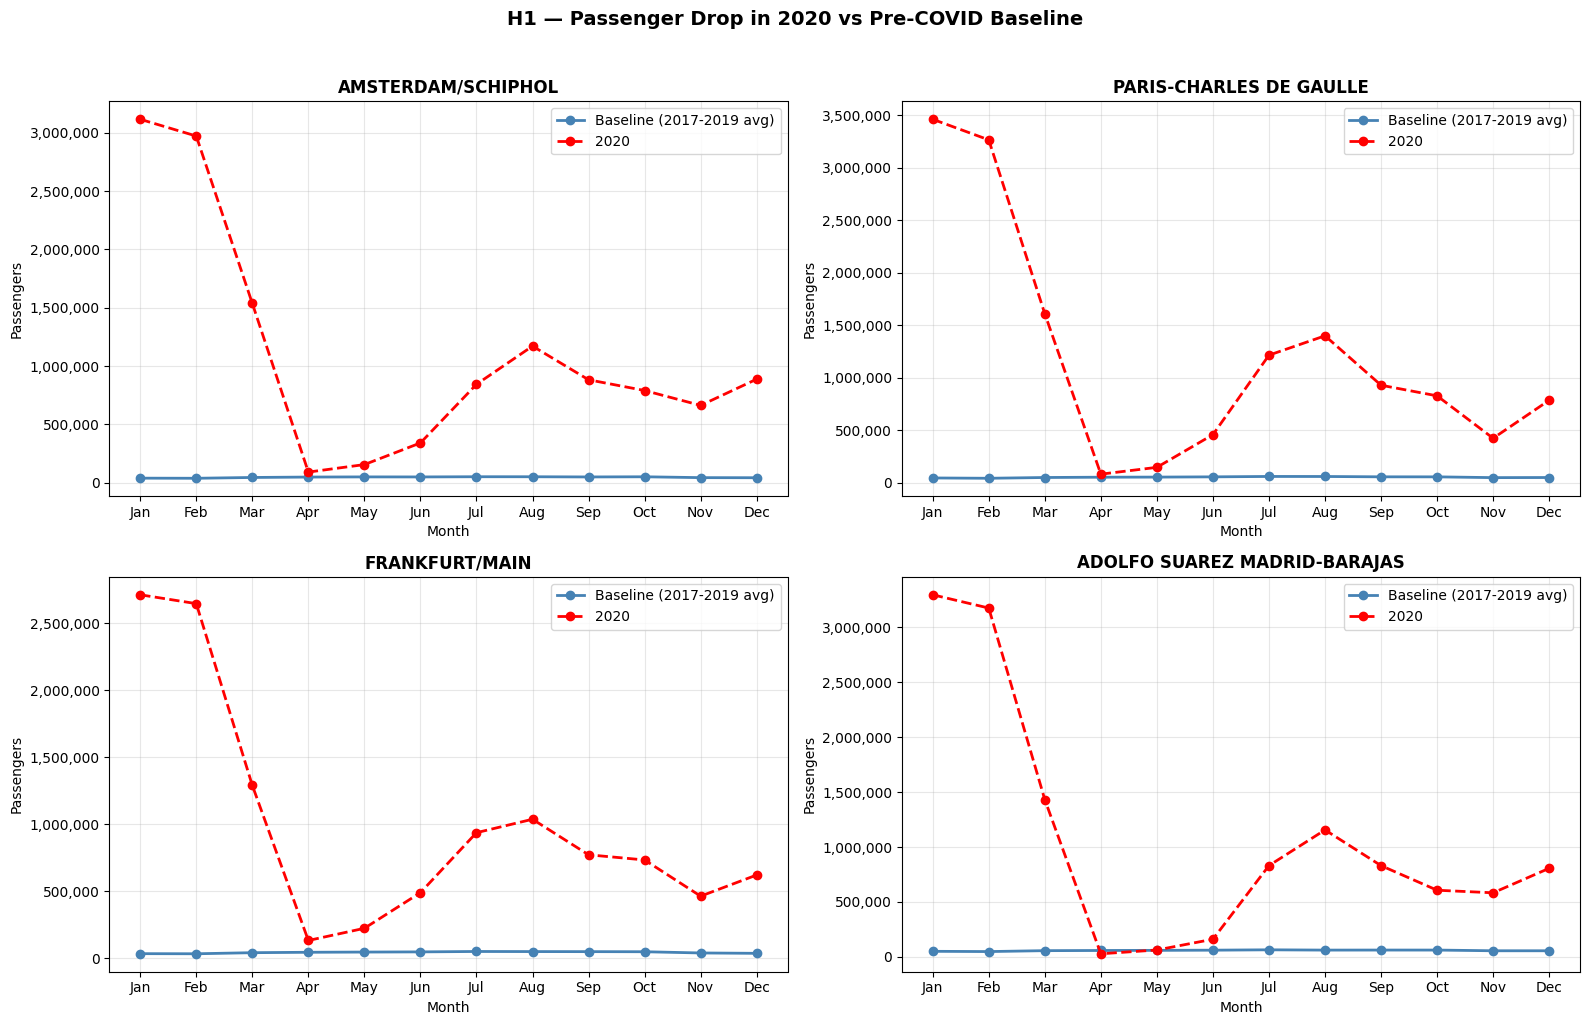

In [114]:


# Step 1 — Calculate monthly baseline average (2017-2019) per airport
baseline = passengers_core[passengers_core["year"].isin([2017, 2018, 2019])]
baseline_monthly = baseline.groupby(["origin", "month"])["passengers"].mean().reset_index()
baseline_monthly = baseline_monthly.rename(columns={"passengers": "baseline_avg"})
baseline_monthly["year"] = "Baseline (2017-2019 avg)"

# Step 2 — Get 2020 monthly data per airport
covid = passengers_core[passengers_core["year"] == 2020]
covid_monthly = covid.groupby(["origin", "month"])["passengers"].sum().reset_index()
covid_monthly = covid_monthly.rename(columns={"passengers": "passengers"})
covid_monthly["year"] = "2020"

# Step 3 — Plot one chart per airport
airports = passengers_core["origin"].unique()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, airport in enumerate(airports):
    ax = axes[i]
    
    # Baseline
    base = baseline_monthly[baseline_monthly["origin"] == airport]
    ax.plot(base["month"], base["baseline_avg"], 
            label="Baseline (2017-2019 avg)", 
            color="steelblue", linewidth=2, marker="o")
    
    # 2020
    cov = covid_monthly[covid_monthly["origin"] == airport]
    ax.plot(cov["month"], cov["passengers"], 
            label="2020", 
            color="red", linewidth=2, marker="o", linestyle="--")
    
    # Formatting
    ax.set_title(airport.replace(" airport", ""), fontsize=12, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Passengers")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("H1 — Passenger Drop in 2020 vs Pre-COVID Baseline", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()